<a href="https://colab.research.google.com/github/muchamad-fabian/IntroDPI_IF6B_0018/blob/main/day_2_Grafkom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/dreve')

Mounted at /content/dreve


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Tipe data: <class 'numpy.ndarray'>
shape      (4000, 6000, 3)
Dtype      uint8

Artinya:
 Tinggi = 4000 piksel
 Lebar  = 6000 piksel
 Chanel = 3 piksel
Ukuran gambar: 70312.50 KB
Ukuran gambar: 68.66 MB
Total piksel:  24000000


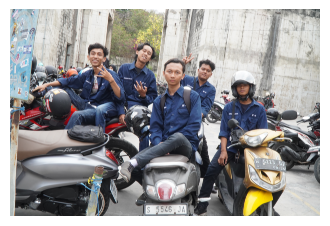

In [50]:
# baca gambar dari file
# cv2.imread)() mengembalikan array numpy
img_bgr = cv2.imread('drive/MyDrive/Colab_Notebooks/img/pria_tampan.JPG')

#Resize agar tidak terlalu besar
print("Tipe data:", type(img_bgr))
print("shape     ", img_bgr.shape)
print("Dtype     ", img_bgr.dtype)

print()
print("Artinya:")
print(f" Tinggi = {img_bgr.shape[0]} piksel")
print(f" Lebar  = {img_bgr.shape[1]} piksel")
print(f" Chanel = {img_bgr.shape[2]} piksel")


#komversi BGR-RGB untuk ditampilkan di mitplotlab
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB);

print('Total piksel: ', img_bgr.shape[0] * img_bgr.shape[1])

plt.figure(figsize=(4, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

==== matriks f(x,y) - area 8x8 piksel ====
setiap angka = nilai intensif 1 piksel (0=Hitam, 255=Putih)

[[194 193 200 199 198 194 194 198]
 [192 196 201 198 197 195 195 198]
 [193 199 200 199 196 196 196 197]
 [198 199 197 200 195 198 198 197]
 [202 199 198 198 195 198 198 198]
 [200 199 200 195 196 197 198 198]
 [198 199 200 195 197 196 197 199]
 [198 199 196 198 198 195 196 199]]

contoh baca : f(180,200) = 194
contoh baca : f(181,201) = 196


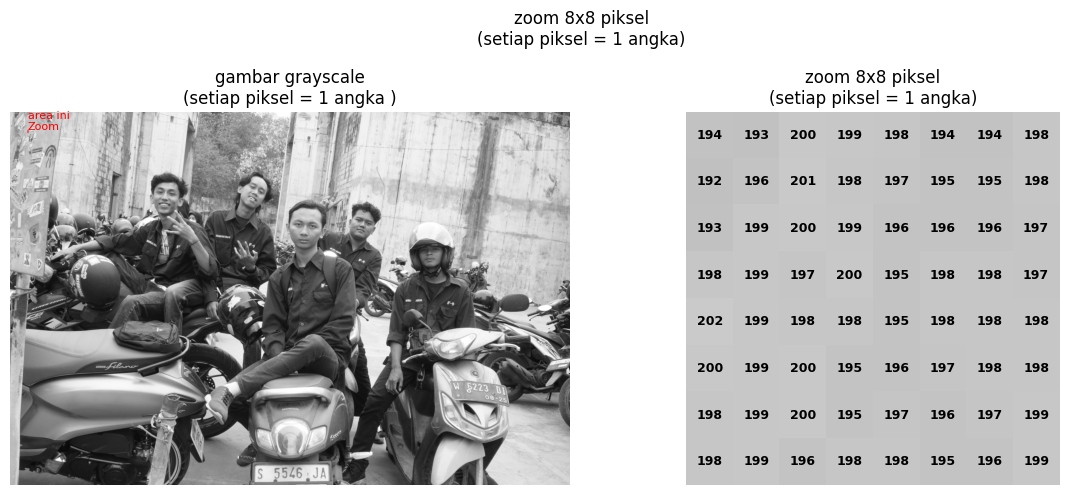

In [18]:
import matplotlib.patches as patches

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

#ambil area kecil 8x8 pixel dari tengah gambar (area tertentu tersebut)
area_kecil = img_gray[200:208, 180:188] # Fixed: changed 200:200 to 200:208 to get an 8x8 area

print ("==== matriks f(x,y) - area 8x8 piksel ====")
print ("setiap angka = nilai intensif 1 piksel (0=Hitam, 255=Putih)")
print ()
print (area_kecil)
print ()
print ("contoh baca :", f"f(180,200) = {img_gray[200, 180]}")
print ("contoh baca :", f"f(181,201) = {img_gray[201, 181]}")

#tampil area kecil dengan angka
fig, axes = plt.subplots(1,2, figsize=(12, 5))


#kiri: gambar grayscale penuh
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('gambar grayscale\n(setiap piksel = 1 angka )') # Fixed: axws to axes
axes[0].axis('off')
#tandai area yang di ZOOM
rect = patches.Rectangle((180,200), 8, 8, linewidth=2, edgecolor='red', facecolor="none") # Fixed: import patches
axes[0].add_patch(rect) # Fixed: axes(0) to axes[0]
axes[0].text(190, 195, 'area ini\nZoom', color='red', fontsize=8) # Fixed: axes(0) to axes[0]

#kanan: tampilkan nilai angka pada setiap piksel
axes[1].imshow(area_kecil,cmap='gray', vmin=0, vmax=255) # Fixed: vmac to vmax
for i in range(8):
    for j in range(8):
      nilai = area_kecil[i, j]
      warna_teks = 'white' if nilai < 128 else 'black' # Fixed: whitem to 'white' and unterminated string literal
      axes [1].text(j, i, str(nilai), ha='center', va='center',
                    fontsize= 9 , color=warna_teks, fontweight = 'bold')
axes[1].set_title('zoom 8x8 piksel\n(setiap piksel = 1 angka)')
axes[1].axis('off')
plt.suptitle('zoom 8x8 piksel\n(setiap piksel = 1 angka)') # Changed subtitle to suptitle for main title
plt.tight_layout()
plt.show()

==== Ukuran Gambar ====
RGB Gambar Asli: (4000, 6000, 3) (Tinggi, Lebar, Channel)
Total Piksel RGB: 24000000 piksel
Grayscale Gambar: (4000, 6000) (Tinggi, Lebar)
Total Piksel Grayscale: 24000000 piksel

==== Matriks Piksel Grayscale (8x8) ====
setiap angka = nilai intensitas 1 piksel (0=Hitam, 255=Putih)
[[194 193 200 199 198 194 194 198]
 [192 196 201 198 197 195 195 198]
 [193 199 200 199 196 196 196 197]
 [198 199 197 200 195 198 198 197]
 [202 199 198 198 195 198 198 198]
 [200 199 200 195 196 197 198 198]
 [198 199 200 195 197 196 197 199]
 [198 199 196 198 198 195 196 199]]

contoh baca Grayscale : f(180,200) = 194
contoh baca Grayscale : f(181,201) = 196

==== Rata-rata Nilai RGB (8x8 Area) ====
Rata-rata R: 176.64
Rata-rata G: 204.45
Rata-rata B: 215.14

Ukuran gambar: 70312.50 KB
Ukuran gambar: 68.66 MB


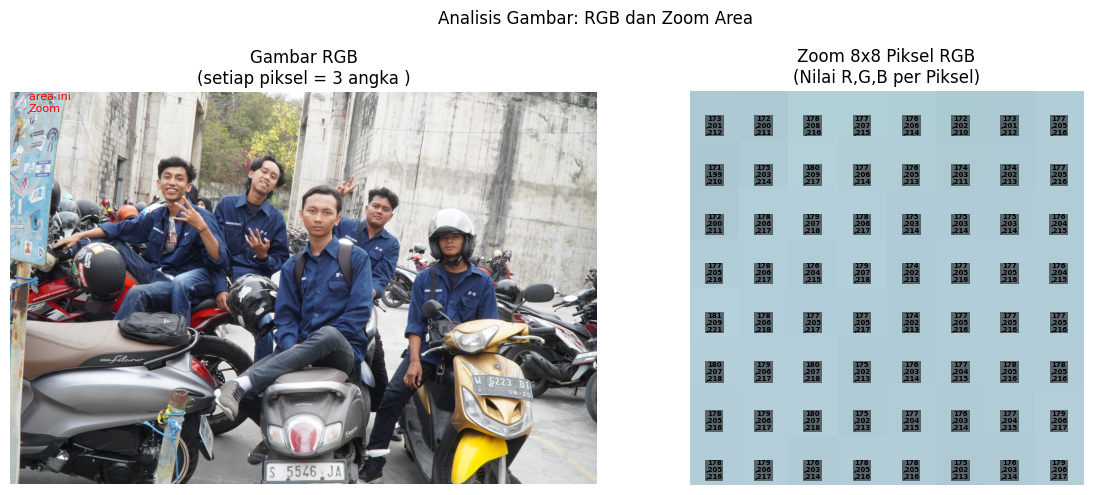

In [52]:
import matplotlib.patches as patches
import numpy as np # Ensure numpy is imported for np.mean

# Grayscale conversion
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# --- Image Size Information ---
print("==== Ukuran Gambar ====")
print(f"RGB Gambar Asli: {img_rgb.shape} (Tinggi, Lebar, Channel)")
print(f"Total Piksel RGB: {img_rgb.shape[0] * img_rgb.shape[1]} piksel")
print(f"Grayscale Gambar: {img_gray.shape} (Tinggi, Lebar)")
print(f"Total Piksel Grayscale: {img_gray.shape[0] * img_gray.shape[1]} piksel")
print()

# ambil area kecil 8x8 pixel dari tengah gambar
area_kecil_gray = img_gray[200:208, 180:188]
area_kecil_rgb = img_rgb[200:208, 180:188]

# --- Pixel Matrix Information ---
print ("==== Matriks Piksel Grayscale (8x8) ====")
print ("setiap angka = nilai intensitas 1 piksel (0=Hitam, 255=Putih)")
print (area_kecil_gray)
print ()
print ("contoh baca Grayscale :", f"f(180,200) = {img_gray[200, 180]}")
print ("contoh baca Grayscale :", f"f(181,201) = {img_gray[201, 181]}")
print()

# Hitung dan tampilkan rata-rata nilai R, G, B dari area kecil RGB
mean_r = np.mean(area_kecil_rgb[:, :, 0])
mean_g = np.mean(area_kecil_rgb[:, :, 1])
mean_b = np.mean(area_kecil_rgb[:, :, 2])

print("==== Rata-rata Nilai RGB (8x8 Area) ====")
print(f"Rata-rata R: {mean_r:.2f}")
print(f"Rata-rata G: {mean_g:.2f}")
print(f"Rata-rata B: {mean_b:.2f}")
print()

# Hitung ukuran gambar dalam KB dan MB
image_size_bytes = img_bgr.nbytes
image_size_kb = image_size_bytes / 1024
image_size_mb = image_size_kb / 1024

print(f"Ukuran gambar: {image_size_kb:.2f} KB")
print(f"Ukuran gambar: {image_size_mb:.2f} MB")

# tampil area kecil dengan angka
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# kiri: gambar RGB penuh
axes[0].imshow(img_rgb)
axes[0].set_title('Gambar RGB\n(setiap piksel = 3 angka )')
axes[0].axis('off')
# tandai area yang di ZOOM
rect = patches.Rectangle((180, 200), 8, 8, linewidth=2, edgecolor='red', facecolor="none")
axes[0].add_patch(rect)
axes[0].text(190, 195, 'area ini\nZoom', color='red', fontsize=8)

# kanan: tampilkan zoom area RGB dengan nilai R, G, B individual
axes[1].imshow(area_kecil_rgb)
for i in range(area_kecil_rgb.shape[0]):
    for j in range(area_kecil_rgb.shape[1]):
        r, g, b = area_kecil_rgb[i, j]
        pixel_text = f"{r}\n,{g}\n,{b}"
        # Determine text color based on perceived brightness for contrast
        # A common formula for perceived brightness (luminance) is 0.299*R + 0.587*G + 0.114*B
        perceived_brightness = (0.299 * r + 0.587 * g + 0.114 * b)
        text_color = 'white' if perceived_brightness < 128 else 'black'
        axes[1].text(j, i, pixel_text, ha='center', va='top', # Changed va from 'center' to 'top'
                     fontsize=5, color=text_color, fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=0.5))
axes[1].set_title('Zoom 8x8 Piksel RGB\n(Nilai R,G,B per Piksel)')
axes[1].axis('off')

plt.suptitle('Analisis Gambar: RGB dan Zoom Area')
plt.tight_layout()
plt.show()